
# 蛋白质检索可视化（高分 query 版本）

这版 notebook 相比上一版的变化：

1. 不再随机选 query，而是对测试集中每个 query 的检索结果计算：
   - `Top1 Remote homologous score`
   - `Top12 mean Remote homologous score`

   然后分别按这两个指标排序，选取得分最高的若干个 query 进行绘制。

2. PyMOL 结构图改为**一个蛋白一张图**，图中**不加任何文字标注**。

3. 蛋白质名（`lab`）、`TM-score`、`SEQID`、`Remote homologous score` 改为在 notebook 输出区 `print`。

4. embedding 可视化**不使用聚类优化**，直接对选中的 query 及其 Top12 candidate 做二维投影可视化。


In [26]:

# ====== 可修改配置 ======
from pathlib import Path

CHECKPOINT_PATH = Path("./checkpoints/TransGINE_AttnPool_TMscore_p1h0/best.pt")   # 改成你的 checkpoint 路径
DATA_PATH = Path("./data/sorted_1300_p1_h0.pt")             # 改成你的数据路径
PAIR_FILE = Path("./data/tmalign.out")                      # 改成你的 pair_file
PDB_ROOT = Path("../../data/pdb")                           # 改成你的 pdb_root
TMALIGN_PATH = Path("./TMalign")                            # 改成你的 TMalign 可执行文件路径

GPU_ID = 0
EVAL_BATCH_SIZE = 32
NUM_WORKERS = 4

TEST_SIZE = 1024
RANDOM_STATE = 42

TOPK_RETRIEVAL = 12            # 检索后用于 TM-align 打分的 candidate 数
SEARCH_K = 200                 # FAISS 初检索数，必须 > TOPK_RETRIEVAL，便于去掉 self-hit
NUM_QUERIES_PER_RANKING = 3    # 每种排序方式（Top1 / Top12 mean）各取多少个 query 做结构图
TOP_CANDIDATES_TO_DRAW = 5     # 每个 query 画多少个 candidate（按 Remote homologous score 排序后取前5）

EMB_QUERIES_PER_RANKING = 3    # 每种排序方式各取多少个 query 做 embedding 可视化
EMB_METHOD = "tsne"            # "tsne" 或 "pca"
EMB_FIGSIZE = (7, 6)

PYMOL_IMG_W = 900
PYMOL_IMG_H = 900
PYMOL_DPI = 300

OUTPUT_DIR = Path("./viz_outputs_highscore")
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)
(OUTPUT_DIR / "images").mkdir(parents=True, exist_ok=True)
(OUTPUT_DIR / "tables").mkdir(parents=True, exist_ok=True)

print("OUTPUT_DIR =", OUTPUT_DIR.resolve())


OUTPUT_DIR = /home/burger/bioinfo/project/viz_outputs_highscore


In [15]:

# ====== 导入依赖 ======
import os
import sys
import math
import random
import warnings
from pathlib import Path

import numpy as np
import pandas as pd
import torch as pt
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.decomposition import PCA

try:
    from sklearn.manifold import TSNE
    HAS_TSNE = True
except Exception:
    HAS_TSNE = False

from torch.utils.data import DataLoader
from IPython.display import display, Image, Markdown

warnings.filterwarnings("ignore", category=FutureWarning)

# 优先使用项目内 utils.*；若 notebook 与 data.py / model.py / tools.py 同目录，则回退到本地导入
try:
    from utils.data import ProteinDataset, QueryHomologyDataset, collate_fun_emb
    from utils.model import DualEncoderRetriever
    from utils.tools import build_idx, calculate_remote_homology_score, gen_embeddings, make_pdb_path
    IMPORT_SOURCE = "utils.*"
except Exception:
    from data import ProteinDataset, QueryHomologyDataset, collate_fun_emb
    from model import DualEncoderRetriever
    from tools import build_idx, calculate_remote_homology_score, gen_embeddings, make_pdb_path
    IMPORT_SOURCE = "local files"

print("Import source:", IMPORT_SOURCE)
print("PyTorch version:", pt.__version__)
print("CUDA available:", pt.cuda.is_available())


Import source: utils.*
PyTorch version: 2.5.1+cu121
CUDA available: True


In [30]:

# ====== 工具函数 ======
def get_device(gpu_id: int = 0):
    return pt.device(f"cuda:{gpu_id}" if pt.cuda.is_available() else "cpu")

def infer_graph_dims(dataset: ProteinDataset):
    sample = dataset[0]["graph"]
    node_feat_dim = int(sample.x.shape[-1])
    if getattr(sample, "edge_attr", None) is None:
        edge_feat_dim = 0
    else:
        edge_feat_dim = int(sample.edge_attr.shape[-1])
    return node_feat_dim, edge_feat_dim

def instantiate_model_from_checkpoint(ckpt_path: Path, lib_data: ProteinDataset, device):
    ckpt = pt.load(ckpt_path, map_location="cpu", weights_only=False)
    if "config" not in ckpt:
        raise KeyError("checkpoint 中未找到 config 字段，无法自动重建模型。")

    cfg = ckpt["config"]
    node_feat_dim, edge_feat_dim = infer_graph_dims(lib_data)

    model = DualEncoderRetriever(
        vocab_size=int(cfg.get("vocab_size", 21)),
        node_feat_dim=node_feat_dim,
        edge_feat_dim=edge_feat_dim,
        hidden_dim=int(cfg.get("hidden_dim", 512)),
        proj_dim=int(cfg.get("proj_dim", 256)),
        gnn_num_layers=int(cfg.get("gnn_num_layers", 3)),
        transformer_num_layers=int(cfg.get("transformer_num_layers", 1)),
        transformer_heads=int(cfg.get("transformer_heads", 8)),
        max_seq_len=int(cfg.get("max_seq_len", 4096)),
        dropout=float(cfg.get("dropout", 0.1)),
        normalize=bool(cfg.get("normalize", True)),
        temperature=float(cfg.get("temperature", 0.07)),
    )

    state_dict = ckpt["model_state_dict"] if "model_state_dict" in ckpt else ckpt
    missing, unexpected = model.load_state_dict(state_dict, strict=False)
    model = model.to(device)
    model.eval()

    print("Loaded checkpoint:", ckpt_path)
    if len(missing) > 0:
        print("[Warning] Missing keys:", missing)
    if len(unexpected) > 0:
        print("[Warning] Unexpected keys:", unexpected)

    return model, ckpt

def filter_self_hits(indices: np.ndarray, query_map: np.ndarray, lib_map: np.ndarray, topk: int):
    filtered = []
    self_hits = 0
    for row, q_global_idx in zip(indices, query_map):
        row_filtered = []
        hit_self = False
        for j_local in row:
            j_local = int(j_local)
            cand_global_idx = int(lib_map[j_local])
            if cand_global_idx == int(q_global_idx):
                hit_self = True
                continue
            row_filtered.append(j_local)
            if len(row_filtered) >= topk:
                break
        filtered.append(row_filtered)
        self_hits += int(hit_self)
    self_hit_rate = self_hits / max(len(query_map), 1)
    return filtered, self_hit_rate

def query_name_from_testset(test_set, lib_data, q_local_idx: int) -> str:
    q_global_idx = int(test_set[q_local_idx]["idx1"])
    return str(lib_data[q_global_idx]["lab"])

def summarize_sorted_results(sorted_results: dict, test_set, lib_data):
    rows = []
    for q_local_idx, cand_list in sorted_results.items():
        q_name = query_name_from_testset(test_set, lib_data, q_local_idx)
        if len(cand_list) == 0:
            rows.append({
                "q_local_idx": q_local_idx,
                "query_lab": q_name,
                "num_valid_candidates": 0,
                "top1_score": np.nan,
                "top1_tm": np.nan,
                "top1_seqid": np.nan,
                "top12_mean_score": np.nan,
                "top12_mean_tm": np.nan,
                "top12_mean_seqid": np.nan,
            })
            continue

        top1 = cand_list[0]
        top12 = cand_list[:12]
        rows.append({
            "q_local_idx": q_local_idx,
            "query_lab": q_name,
            "num_valid_candidates": len(cand_list),
            "top1_score": float(top1["score"]),
            "top1_tm": float(top1["tm_score"]),
            "top1_seqid": float(top1["seqid"]),
            "top12_mean_score": float(np.mean([x["score"] for x in top12])),
            "top12_mean_tm": float(np.mean([x["tm_score"] for x in top12])),
            "top12_mean_seqid": float(np.mean([x["seqid"] for x in top12])),
        })
    df = pd.DataFrame(rows).sort_values("q_local_idx").reset_index(drop=True)
    return df

def select_queries(summary_df: pd.DataFrame, mode: str, n: int):
    if mode == "top1":
        key = "top1_score"
    elif mode == "top12_mean":
        key = "top12_mean_score"
    else:
        raise ValueError("mode must be 'top1' or 'top12_mean'")
    out = summary_df.dropna(subset=[key]).sort_values(key, ascending=False).head(n).copy()
    out["ranking_mode"] = mode
    return out.reset_index(drop=True)

def ensure_pymol():
    try:
        import pymol  # noqa: F401
        from pymol import cmd  # noqa: F401
        return True
    except Exception as e:
        print("无法导入 pymol。请确认当前 Jupyter kernel 使用的是安装了 PyMOL 的 conda 环境。")
        print("错误信息：", repr(e))
        return False

def render_single_protein_png(pdb_path: Path, out_png: Path, width=900, height=900, dpi=200):
    import pymol
    from pymol import cmd

    cmd.reinitialize()
    cmd.set("ray_opaque_background", 0)
    cmd.bg_color("white")
    cmd.load(str(pdb_path), "prot")
    cmd.hide("everything", "all")
    cmd.show("cartoon", "prot")
    cmd.remove("solvent")
    cmd.orient("prot")
    cmd.spectrum("count", "rainbow", "prot")
    cmd.set("antialias", 2)
    cmd.set("cartoon_fancy_helices", 1)
    cmd.set("orthoscopic", 1)
    cmd.set("ray_trace_mode", 1)
    cmd.png(str(out_png), width=width, height=height, dpi=dpi, ray=1)

def display_png(path: Path, width: int = 350):
    display(Image(filename=str(path), width=width))

def print_candidate_block(query_lab, ranking_mode, q_local_idx, cand_list, lib_data, topn=5):
    print("=" * 100)
    print(f"[{ranking_mode}] q_local_idx={q_local_idx} | query_lab={query_lab}")
    print("-" * 100)
    for rank, item in enumerate(cand_list[:topn], start=1):
        cand_lab = str(lib_data[int(item["c_idx"])]["lab"])
        print(
            f"Rank {rank:>2d} | candidate_lab={cand_lab} | "
            f"TM-score={item['tm_score']:.4f} | SEQID={item['seqid']:.4f} | "
            f"Remote homologous score={item['score']:.4f}"
        )
    print("=" * 100)

def get_selected_query_indices(summary_df, per_mode=3):
    qids = []
    for mode in ["top1", "top12_mean"]:
        sel = select_queries(summary_df, mode=mode, n=per_mode)
        qids.extend(sel["q_local_idx"].tolist())
    # 去重并保持顺序
    seen = set()
    out = []
    for q in qids:
        if q not in seen:
            seen.add(q)
            out.append(int(q))
    return out

def reduce_embeddings_2d(X: np.ndarray, method="tsne", random_state=42):
    X = np.asarray(X, dtype=np.float32)
    n = X.shape[0]
    if n <= 2:
        if X.shape[1] >= 2:
            return X[:, :2]
        out = np.zeros((n, 2), dtype=np.float32)
        out[:, :X.shape[1]] = X
        return out

    if method == "tsne" and HAS_TSNE:
        perplexity = max(2, min(5, n - 1))
        try:
            reducer = TSNE(
                n_components=2,
                perplexity=perplexity,
                init="pca",
                learning_rate="auto",
                random_state=random_state,
            )
            return reducer.fit_transform(X)
        except Exception as e:
            print("[Warning] TSNE 失败，回退到 PCA：", repr(e))

    reducer = PCA(n_components=2, random_state=random_state)
    return reducer.fit_transform(X)

def plot_query_and_candidates_embedding(q_local_idx, sorted_results, test_set, lib_data, embs_test, embs_lib,
                                       topk=12, method="tsne", figsize=(7, 6), title_prefix="",
                                       save_path=None):
    query_lab = query_name_from_testset(test_set, lib_data, q_local_idx)
    cand_list = sorted_results[q_local_idx][:topk]
    cand_indices = [int(x["c_idx"]) for x in cand_list]
    cand_labs = [str(lib_data[i]["lab"]) for i in cand_indices]

    X = np.concatenate([
        embs_test[q_local_idx:q_local_idx+1],
        embs_lib[cand_indices],
    ], axis=0)

    X2 = reduce_embeddings_2d(X, method=method, random_state=42 + int(q_local_idx))

    fig, ax = plt.subplots(figsize=figsize)
    # 前5名 candidate 用三角
    top5_end = min(6, len(X2))   # X2[0] 是 query，所以 X2[1:6] 对应前5名 candidate
    if top5_end > 1:
        ax.scatter(
            X2[1:top5_end, 0],
            X2[1:top5_end, 1],
            s=70,
            alpha=0.9,
            marker="^",
            label="Top5 Candidates"
        )

    # 其余 candidate 保持圆点
    if len(X2) > top5_end:
        ax.scatter(
            X2[top5_end:, 0],
            X2[top5_end:, 1],
            s=60,
            alpha=0.85,
            marker="o",
            label="Other Candidates"
        )
    ax.scatter(X2[0, 0], X2[0, 1], s=180, marker="*", label="Query")

    ax.annotate(query_lab, (X2[0, 0], X2[0, 1]), xytext=(6, 6), textcoords="offset points", fontsize=10)
    for i, lab in enumerate(cand_labs, start=1):
        ax.annotate(lab, (X2[i, 0], X2[i, 1]), xytext=(4, 4), textcoords="offset points", fontsize=8)

    ax.set_title(f"{title_prefix} query={query_lab} | top{topk} candidates | method={method}")
    ax.legend()
    ax.grid(True, alpha=0.3)

    if save_path is not None:
            save_path = Path(save_path)
            save_path.parent.mkdir(parents=True, exist_ok=True)
            fig.savefig(save_path, format="svg", bbox_inches="tight", dpi=500)
            print("Saved:", save_path)

    plt.show()

def save_summary_tables(summary_df: pd.DataFrame, output_dir: Path):
    summary_path = output_dir / "tables" / "query_score_summary.csv"
    summary_df.to_csv(summary_path, index=False)

    top1_path = output_dir / "tables" / "top_queries_by_top1_score.csv"
    top12_path = output_dir / "tables" / "top_queries_by_top12_mean_score.csv"
    select_queries(summary_df, "top1", len(summary_df)).to_csv(top1_path, index=False)
    select_queries(summary_df, "top12_mean", len(summary_df)).to_csv(top12_path, index=False)

    print("Saved:")
    print(" -", summary_path)
    print(" -", top1_path)
    print(" -", top12_path)


In [17]:

# ====== 载入数据，复现 train.py 的测试集划分 ======
device = get_device(GPU_ID)
print("Using device:", device)

data = pt.load(DATA_PATH, map_location="cpu", weights_only=False)
lib_data = ProteinDataset(data, mode="graph")
lib_map = np.arange(len(lib_data), dtype=np.int64)
pdb2idx = {str(lib_data[i]["lab"]): i for i in range(len(lib_data))}

queryhomo = QueryHomologyDataset(None, str(PAIR_FILE), pdb2idx)
all_query_map = np.arange(len(queryhomo), dtype=np.int64)
train_map, test_map = train_test_split(
    all_query_map,
    test_size=TEST_SIZE,
    random_state=RANDOM_STATE,
)
test_map = np.sort(test_map)

test_set = QueryHomologyDataset(queryhomo, mapping=test_map)
test_global_idx = np.array([int(test_set[i]["idx1"]) for i in range(len(test_set))], dtype=np.int64)

print("Library size:", len(lib_data))
print("All query groups:", len(queryhomo))
print("Test queries:", len(test_set))
print("Unique test query proteins:", len(np.unique(test_global_idx)))


Using device: cuda:0
Library size: 106663
All query groups: 30646
Test queries: 1024
Unique test query proteins: 1024


In [18]:

# ====== 构建 dataloader 并加载 checkpoint ======
lib_loader = DataLoader(
    lib_data,
    batch_size=EVAL_BATCH_SIZE,
    shuffle=False,
    pin_memory=True,
    num_workers=NUM_WORKERS,
    collate_fn=collate_fun_emb(mode="cand"),
)

test_loader = DataLoader(
    test_set,
    batch_size=EVAL_BATCH_SIZE,
    shuffle=False,
    pin_memory=True,
    num_workers=NUM_WORKERS,
    collate_fn=collate_fun_emb(mode="query", protein_dataset=lib_data),
)

model, ckpt = instantiate_model_from_checkpoint(CHECKPOINT_PATH, lib_data, device)
cfg = ckpt.get("config", {})
print("Checkpoint epoch:", ckpt.get("epoch", "N/A"))
print("Checkpoint monitor metrics:", ckpt.get("metrics", {}))


Loaded checkpoint: checkpoints/TransGINE_AttnPool_TMscore_p1h0/best.pt
Checkpoint epoch: 80
Checkpoint monitor metrics: {'self_hit_rate': 1.0, 'search_k': 200, 'avg_top1_score': 0.18238067382812503, 'avg_topk_score': 0.015646587727864623, 'avg_top1_tm': 0.7992849707031252, 'avg_top1_seqid': 0.2879931640624997}


/home/burger/miniconda3/envs/cu121/lib/python3.11/site-packages/torch/nn/modules/transformer.py:379: UserWarning: enable_nested_tensor is True, but self.use_nested_tensor is False because encoder_layer.norm_first was True
  warnings.warn(


In [19]:

# ====== 编码并检索 ======
embs_lib = gen_embeddings(model=model, loader=lib_loader, device=device, normalize_output=False)
embs_test = gen_embeddings(model=model, loader=test_loader, device=device, normalize_output=False)

search_k = max(SEARCH_K, TOPK_RETRIEVAL + 1)
indices_raw, scores_raw = build_idx(embs_lib, embs_test, topk=search_k)
indices_filtered, self_hit_rate = filter_self_hits(indices_raw, test_global_idx, lib_map, topk=TOPK_RETRIEVAL)

print("embs_lib shape:", embs_lib.shape)
print("embs_test shape:", embs_test.shape)
print("self_hit_rate before filtering:", f"{self_hit_rate:.4f}")


faiss cpu searching time: 0:00:00.097983
embs_lib shape: (106663, 256)
embs_test shape: (1024, 256)
self_hit_rate before filtering: 1.0000


In [20]:

# ====== 计算每个 query 的 Top12 candidate 的 TM-score / SEQID / Remote homologous score ======
sorted_results, avg_top1_score, avg_topk_score, avg_top1_tm, avg_top1_seqid = calculate_remote_homology_score(
    query=test_set,
    database=lib_data,
    idx=indices_filtered,
    k=TOPK_RETRIEVAL,
    pdb_root=str(PDB_ROOT),
    tmalign_path=str(TMALIGN_PATH),
    reference=int(cfg.get("tmalign_reference", 1)),
    num_workers=cfg.get("tmalign_workers", None),
)

print(f"Average Top1 score       : {avg_top1_score:.4f}")
print(f"Average Top12 mean score : {avg_topk_score:.4f}")
print(f"Average Top1 TM-score    : {avg_top1_tm:.4f}")
print(f"Average Top1 SEQID       : {avg_top1_seqid:.4f}")


Average Top1 score       : 0.1824
Average Top12 mean score : 0.0156
Average Top1 TM-score    : 0.7993
Average Top1 SEQID       : 0.2880


In [21]:

# ====== 汇总每个 query 的得分，并分别按 Top1 / Top12 mean 排序 ======
summary_df = summarize_sorted_results(sorted_results, test_set, lib_data)
save_summary_tables(summary_df, OUTPUT_DIR)

top_by_top1 = select_queries(summary_df, mode="top1", n=NUM_QUERIES_PER_RANKING)
top_by_top12 = select_queries(summary_df, mode="top12_mean", n=NUM_QUERIES_PER_RANKING)

display(Markdown("## 按 Top1 Remote homologous score 排序"))
display(top_by_top1)

display(Markdown("## 按 Top12 mean Remote homologous score 排序"))
display(top_by_top12)


Saved:
 - viz_outputs_highscore/tables/query_score_summary.csv
 - viz_outputs_highscore/tables/top_queries_by_top1_score.csv
 - viz_outputs_highscore/tables/top_queries_by_top12_mean_score.csv


## 按 Top1 Remote homologous score 排序

,q_local_idx,query_lab,num_valid_candidates,top1_score,top1_tm,top1_seqid,top12_mean_score,top12_mean_tm,top12_mean_seqid,ranking_mode
0,641,4P53-A,12,0.37862,0.97862,0.398,0.197051,0.797051,0.218333,top1
1,362,1IVH-A,12,0.36338,0.96338,0.364,0.335340,0.935340,0.337583,top1
2,646,1P9B-A,12,0.36188,0.96188,0.391,0.301268,0.920685,0.411667,top1


## 按 Top12 mean Remote homologous score 排序

,q_local_idx,query_lab,num_valid_candidates,top1_score,top1_tm,top1_seqid,top12_mean_score,top12_mean_tm,top12_mean_seqid,ranking_mode
0,566,5NCW-A,12,0.34518,0.94518,0.271,0.336685,0.936685,0.276833,top12_mean
1,362,1IVH-A,12,0.36338,0.96338,0.364,0.335340,0.935340,0.337583,top12_mean
2,382,1J93-A,12,0.34878,0.94878,0.371,0.333902,0.933902,0.347833,top12_mean



########################################################################################################################
[top1] query local idx = 641 | query lab = 4P53-A
query pdb: ../../data/pdb/P5/4P53-A.pdb
query image: viz_outputs_highscore/images/top1/qidx_0641_4P53-A/query_4P53-A.png
########################################################################################################################


### Query: `4P53-A`

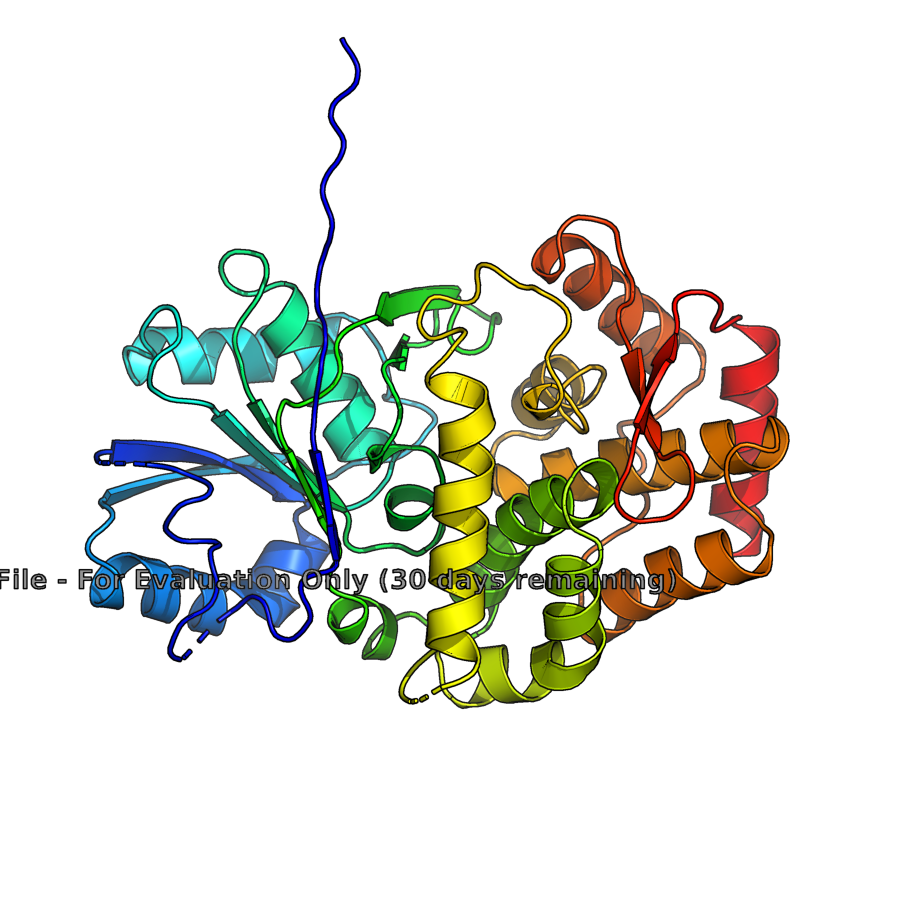

[top1] q_local_idx=641 | query_lab=4P53-A
----------------------------------------------------------------------------------------------------
Rank  1 | candidate_lab=5TPR-A | TM-score=0.9786 | SEQID=0.3980 | Remote homologous score=0.3786
Rank  2 | candidate_lab=3ZOK-A | TM-score=0.8892 | SEQID=0.2810 | Remote homologous score=0.2892
Rank  3 | candidate_lab=5EKS-A | TM-score=0.8733 | SEQID=0.2700 | Remote homologous score=0.2733
Rank  4 | candidate_lab=3OKF-A | TM-score=0.8620 | SEQID=0.2960 | Remote homologous score=0.2620
Rank  5 | candidate_lab=3QBD-A | TM-score=0.8512 | SEQID=0.2630 | Remote homologous score=0.2512


KeyboardInterrupt: 

In [25]:

# ====== 用 PyMOL 绘制：单蛋白单图，不在图上加任何标注；蛋白名和指标通过 print 输出 ======
assert ensure_pymol(), "请切换到安装了 PyMOL 的 conda 环境后再运行本单元。"

def render_query_and_top_candidates(q_local_idx: int, ranking_mode: str, topn: int = 5):
    query_lab = query_name_from_testset(test_set, lib_data, q_local_idx)
    query_pdb = make_pdb_path(PDB_ROOT, query_lab)

    q_dir = OUTPUT_DIR / "images" / ranking_mode / f"qidx_{q_local_idx:04d}_{query_lab}"
    q_dir.mkdir(parents=True, exist_ok=True)

    query_png = q_dir / f"query_{query_lab}.png"
    render_single_protein_png(query_pdb, query_png, width=PYMOL_IMG_W, height=PYMOL_IMG_H, dpi=PYMOL_DPI)

    print("\n" + "#" * 120)
    print(f"[{ranking_mode}] query local idx = {q_local_idx} | query lab = {query_lab}")
    print(f"query pdb: {query_pdb}")
    print(f"query image: {query_png}")
    print("#" * 120)
    display(Markdown(f"### Query: `{query_lab}`"))
    display_png(query_png, width=320)

    cand_list = sorted_results[q_local_idx][:topn]
    print_candidate_block(query_lab, ranking_mode, q_local_idx, cand_list, lib_data, topn=topn)

    for rank, item in enumerate(cand_list, start=1):
        cand_lab = str(lib_data[int(item["c_idx"])]["lab"])
        cand_pdb = make_pdb_path(PDB_ROOT, cand_lab)
        cand_png = q_dir / f"rank{rank:02d}_{cand_lab}.png"

        render_single_protein_png(cand_pdb, cand_png, width=PYMOL_IMG_W, height=PYMOL_IMG_H, dpi=PYMOL_DPI)

        print(
            f"[{ranking_mode}] Rank {rank:>2d} | lab={cand_lab} | "
            f"TM-score={item['tm_score']:.4f} | SEQID={item['seqid']:.4f} | "
            f"Remote homologous score={item['score']:.4f}"
        )
        print(f"candidate pdb: {cand_pdb}")
        print(f"candidate image: {cand_png}\n")

        display(Markdown(f"**Candidate Rank {rank}: `{cand_lab}`**"))
        display_png(cand_png, width=320)

# 先画按 Top1 score 排序得到的 query
for _, row in top_by_top1.iterrows():
    render_query_and_top_candidates(
        q_local_idx=int(row["q_local_idx"]),
        ranking_mode="top1",
        topn=TOP_CANDIDATES_TO_DRAW,
    )

# 再画按 Top12 mean score 排序得到的 query
for _, row in top_by_top12.iterrows():
    render_query_and_top_candidates(
        q_local_idx=int(row["q_local_idx"]),
        ranking_mode="top12_mean",
        topn=TOP_CANDIDATES_TO_DRAW,
    )


Selected query local indices for embedding visualization: [641, 362, 646, 566, 382]

query local idx = 641 | query lab = 4P53-A
Top1 score = 0.3786 | Top12 mean score = 0.1971
Saved: viz_outputs_highscore/images/embedding_svg/qidx_0641_4P53-A.svg


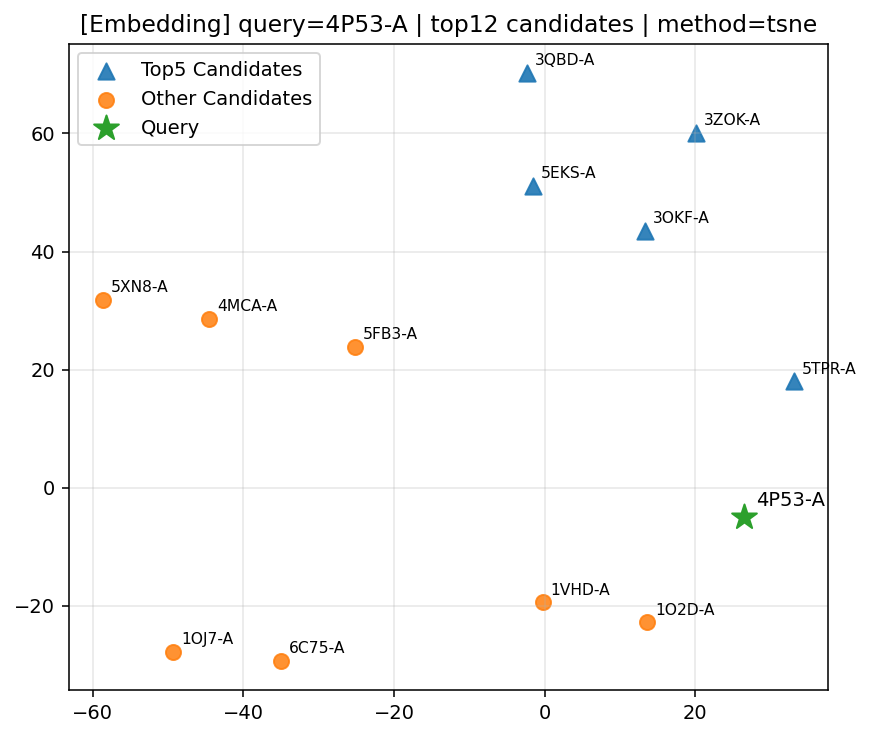


query local idx = 362 | query lab = 1IVH-A
Top1 score = 0.3634 | Top12 mean score = 0.3353
Saved: viz_outputs_highscore/images/embedding_svg/qidx_0362_1IVH-A.svg


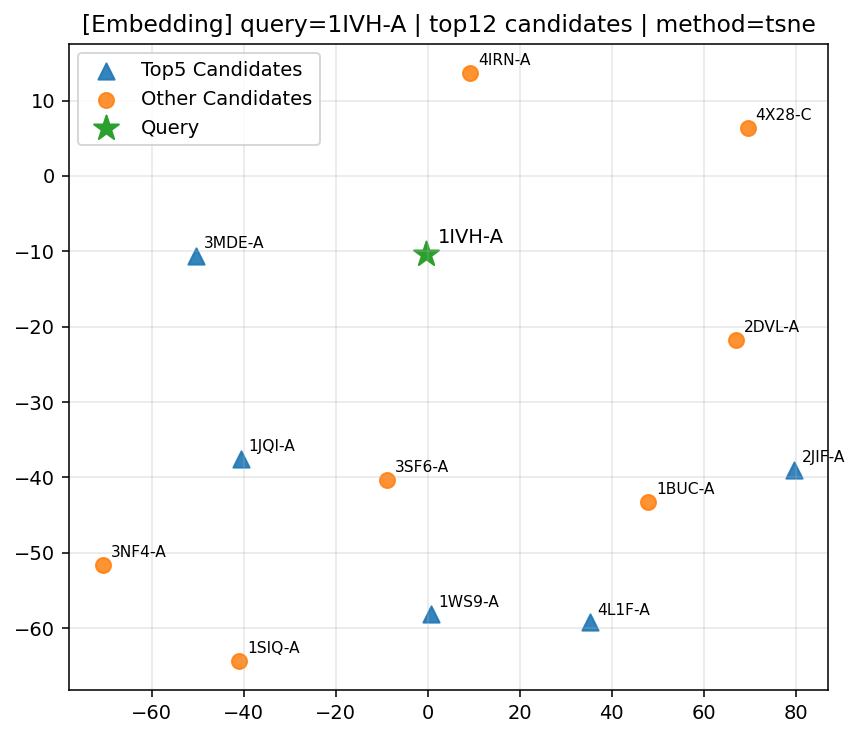


query local idx = 646 | query lab = 1P9B-A
Top1 score = 0.3619 | Top12 mean score = 0.3013
Saved: viz_outputs_highscore/images/embedding_svg/qidx_0646_1P9B-A.svg


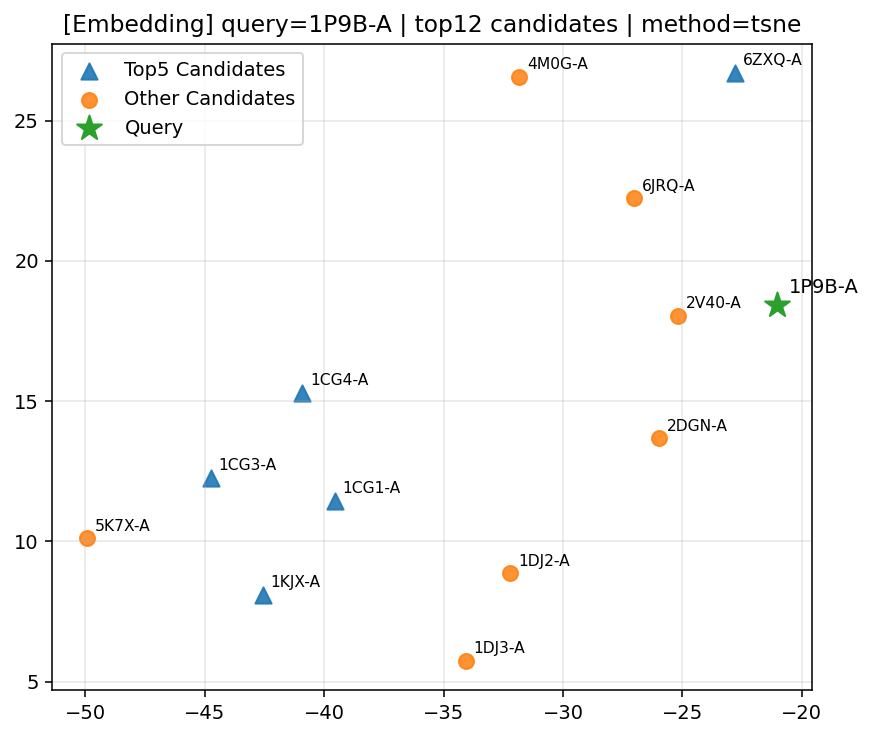


query local idx = 566 | query lab = 5NCW-A
Top1 score = 0.3452 | Top12 mean score = 0.3367
Saved: viz_outputs_highscore/images/embedding_svg/qidx_0566_5NCW-A.svg


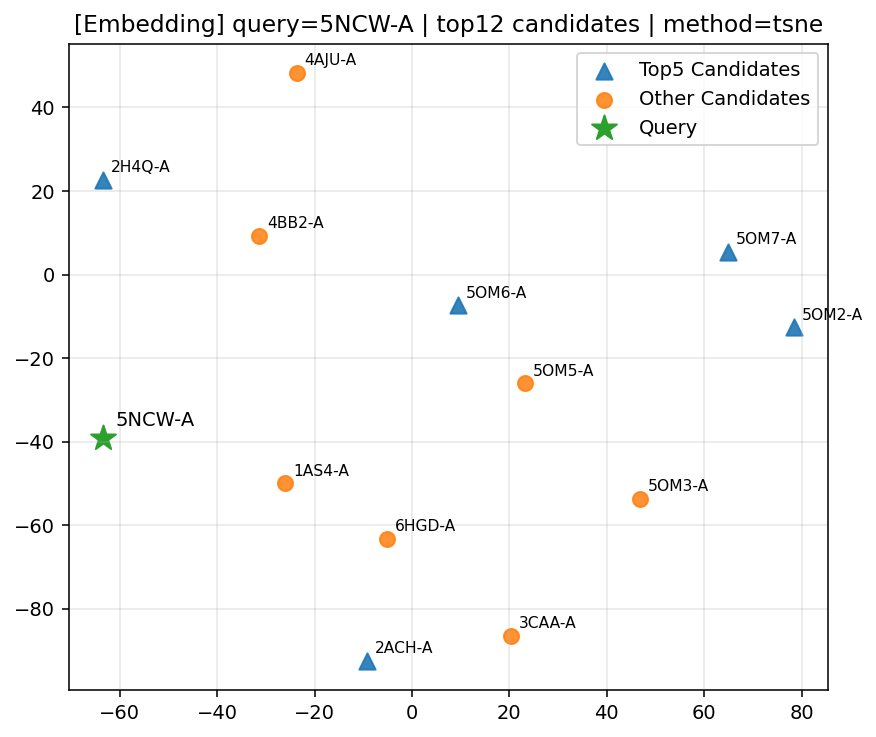


query local idx = 382 | query lab = 1J93-A
Top1 score = 0.3488 | Top12 mean score = 0.3339
Saved: viz_outputs_highscore/images/embedding_svg/qidx_0382_1J93-A.svg


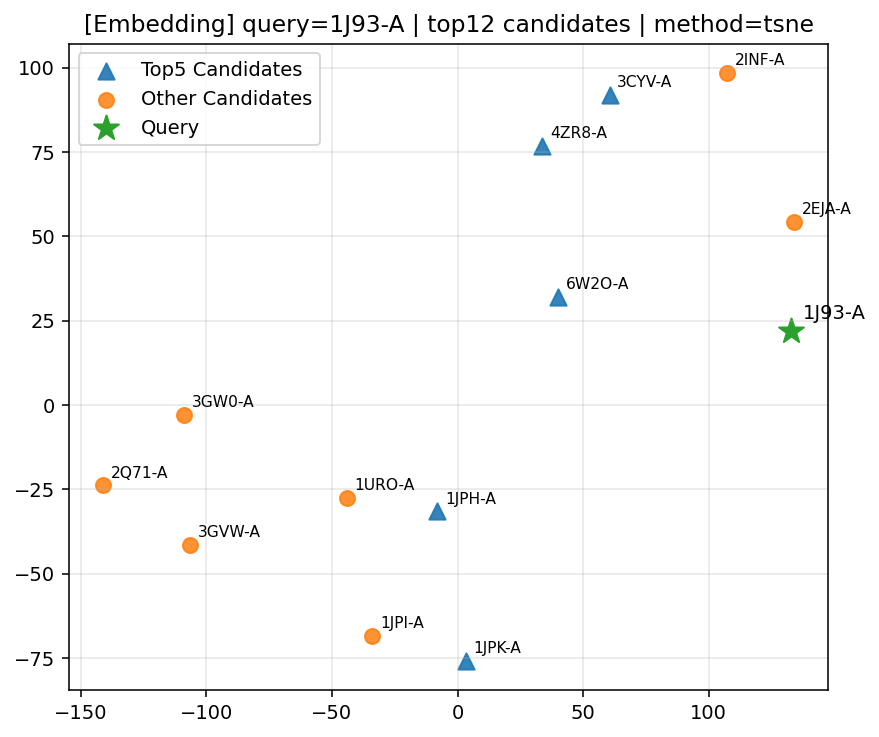

In [31]:

# ====== embedding 可视化：不做聚类优化，直接画 query + 对应 top12 candidate ======
selected_qids_for_emb = get_selected_query_indices(summary_df, per_mode=EMB_QUERIES_PER_RANKING)
print("Selected query local indices for embedding visualization:", selected_qids_for_emb)

for q_local_idx in selected_qids_for_emb:
    query_lab = query_name_from_testset(test_set, lib_data, q_local_idx)
    top1_score = summary_df.loc[summary_df["q_local_idx"] == q_local_idx, "top1_score"].iloc[0]
    top12_mean_score = summary_df.loc[summary_df["q_local_idx"] == q_local_idx, "top12_mean_score"].iloc[0]

    print("\n" + "=" * 120)
    print(f"query local idx = {q_local_idx} | query lab = {query_lab}")
    print(f"Top1 score = {top1_score:.4f} | Top12 mean score = {top12_mean_score:.4f}")
    print("=" * 120)

    emb_svg = OUTPUT_DIR / "images" / "embedding_svg" / f"qidx_{q_local_idx:04d}_{query_lab}.svg"
    plot_query_and_candidates_embedding(
        q_local_idx=q_local_idx,
        sorted_results=sorted_results,
        test_set=test_set,
        lib_data=lib_data,
        embs_test=embs_test,
        embs_lib=embs_lib,
        topk=TOPK_RETRIEVAL,
        method=EMB_METHOD,
        figsize=EMB_FIGSIZE,
        title_prefix="[Embedding]",
        save_path=emb_svg,
    )

In [24]:

# ====== 可选：把选中的 query / candidate 信息单独保存成文本清单，便于论文写图注 ======
selected_records = []

for mode_name, top_df in [("top1", top_by_top1), ("top12_mean", top_by_top12)]:
    for _, row in top_df.iterrows():
        q_local_idx = int(row["q_local_idx"])
        query_lab = query_name_from_testset(test_set, lib_data, q_local_idx)
        for rank, item in enumerate(sorted_results[q_local_idx][:TOP_CANDIDATES_TO_DRAW], start=1):
            cand_lab = str(lib_data[int(item["c_idx"])]["lab"])
            selected_records.append({
                "ranking_mode": mode_name,
                "q_local_idx": q_local_idx,
                "query_lab": query_lab,
                "candidate_rank": rank,
                "candidate_lab": cand_lab,
                "tm_score": float(item["tm_score"]),
                "seqid": float(item["seqid"]),
                "remote_homologous_score": float(item["score"]),
            })

selected_df = pd.DataFrame(selected_records)
selected_path = OUTPUT_DIR / "tables" / "selected_query_candidate_metrics.csv"
selected_df.to_csv(selected_path, index=False)
display(selected_df.head(20))
print("Saved:", selected_path)


,ranking_mode,q_local_idx,query_lab,candidate_rank,candidate_lab,tm_score,seqid,remote_homologous_score
0,top1,641,4P53-A,1,5TPR-A,0.97862,0.398,0.37862
1,top1,641,4P53-A,2,3ZOK-A,0.88923,0.281,0.28923
2,top1,641,4P53-A,3,5EKS-A,0.87332,0.270,0.27332
3,top1,641,4P53-A,4,3OKF-A,0.86197,0.296,0.26197
4,top1,641,4P53-A,5,3QBD-A,0.85125,0.263,0.25125
5,top1,362,1IVH-A,1,1JQI-A,0.96338,0.364,0.36338
6,top1,362,1IVH-A,2,1WS9-A,0.95466,0.371,0.35466
7,top1,362,1IVH-A,3,2JIF-A,0.95370,0.340,0.35370
8,top1,362,1IVH-A,4,4L1F-A,0.95260,0.391,0.35260
9,top1,362,1IVH-A,5,3MDE-A,0.94818,0.339,0.34818


Saved: viz_outputs_highscore/tables/selected_query_candidate_metrics.csv
